# EDA: 20 Newsgroups, RCV1-v2, LectureBank

## Setup

In [1]:
# Install packages
!pip install -q datasets nltk


In [2]:
# Imports
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import sent_tokenize


In [3]:
# Helper functions used across all datasets

def basic_stats(docs, name):
    # Returns dict of basic length statistics
    n = len(docs)
    char_lens = [len(d) for d in docs]
    word_lens = [len(d.split()) for d in docs]
    return {
        'dataset': name,
        'n_docs': n,
        'chars_mean': np.mean(char_lens),
        'chars_median': np.median(char_lens),
        'chars_min': np.min(char_lens),
        'chars_max': np.max(char_lens),
        'words_mean': np.mean(word_lens),
        'words_median': np.median(word_lens),
        'words_min': np.min(word_lens),
        'words_max': np.max(word_lens),
    }

def sentence_counts(docs, sample_size=None):
    # Count sentences per doc; sample if dataset is large
    if sample_size and len(docs) > sample_size:
        rng = np.random.default_rng(42)
        idx = rng.choice(len(docs), size=sample_size, replace=False)
        sampled = [docs[i] for i in idx]
    else:
        sampled = docs
    return [len(sent_tokenize(d)) for d in sampled]

def length_distribution_plot(word_lens, title):
    # Histogram of word lengths clipped at 99th percentile
    cap = int(np.percentile(word_lens, 99))
    plt.figure(figsize=(7, 3))
    plt.hist(np.clip(word_lens, 0, cap), bins=50)
    plt.xlabel('Words per document (clipped at 99th pctl)')
    plt.ylabel('Frequency')
    plt.title(title)
    plt.tight_layout()
    plt.show()

def vocab_stats(docs, sample_size=20000):
    # Vocabulary statistics on a sample
    if len(docs) > sample_size:
        rng = np.random.default_rng(42)
        idx = rng.choice(len(docs), size=sample_size, replace=False)
        sampled = [docs[i] for i in idx]
    else:
        sampled = docs
    counter = Counter()
    total_tokens = 0
    for d in sampled:
        toks = re.findall(r"[A-Za-z']+", d.lower())
        counter.update(toks)
        total_tokens += len(toks)
    vocab_size = len(counter)
    hapax = sum(1 for _, c in counter.items() if c == 1)
    return {
        'sample_docs': len(sampled),
        'total_tokens': total_tokens,
        'vocab_size': vocab_size,
        'hapax_count': hapax,
        'hapax_ratio': hapax / vocab_size if vocab_size else 0,
        'top_20': counter.most_common(20),
    }

def short_noisy_proportion(docs, min_words=20, min_sents=2):
    # Proportion of docs too short for sentence-level modelling
    too_short_words = sum(1 for d in docs if len(d.split()) < min_words)
    if len(docs) <= 5000:
        sc = [len(sent_tokenize(d)) for d in docs]
        denom = len(docs)
    else:
        rng = np.random.default_rng(42)
        idx = rng.choice(len(docs), size=5000, replace=False)
        sc = [len(sent_tokenize(docs[i])) for i in idx]
        denom = 5000
    too_few_sents = sum(1 for c in sc if c < min_sents)
    return {
        'n_total': len(docs),
        'too_short_words_count': too_short_words,
        'too_short_words_pct': 100 * too_short_words / len(docs),
        'too_few_sents_pct (sampled)': 100 * too_few_sents / denom,
    }

def show_examples(docs, labels=None):
    # Show one short, one medium, one long doc by word count
    word_lens = np.array([len(d.split()) for d in docs])
    short_idx = int(np.argmin(word_lens))
    long_idx = int(np.argmax(word_lens))
    median_val = np.median(word_lens)
    med_idx = int(np.argmin(np.abs(word_lens - median_val)))
    for tag, i in [('SHORT', short_idx), ('MEDIUM', med_idx), ('LONG', long_idx)]:
        print(f"--- {tag} (words={word_lens[i]}) ---")
        if labels is not None:
            print(f"label: {labels[i]}")
        print(docs[i][:600])
        print()


## 1. 20 Newsgroups

In [4]:
# Load 20 Newsgroups via sklearn
from sklearn.datasets import fetch_20newsgroups

# remove headers/footers/quotes for cleaner body text
ng_clean = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))

ng_docs = ng_clean.data
ng_labels = [ng_clean.target_names[t] for t in ng_clean.target]
print('docs:', len(ng_docs), '| classes:', len(ng_clean.target_names))


docs: 18846 | classes: 20


In [5]:
# Document count + basic length stats
ng_stats = basic_stats(ng_docs, '20 Newsgroups')
pd.Series(ng_stats)


,0
dataset,20 Newsgroups
n_docs,18846
chars_mean,1169.667516
chars_median,489.0
chars_min,0
chars_max,158791
words_mean,181.637748
words_median,83.0
words_min,0
words_max,11765


rec.sport.hockey            999
soc.religion.christian      997
rec.motorcycles             996
rec.sport.baseball          994
sci.crypt                   991
rec.autos                   990
sci.med                     990
comp.windows.x              988
sci.space                   987
comp.os.ms-windows.misc     985
sci.electronics             984
comp.sys.ibm.pc.hardware    982
misc.forsale                975
comp.graphics               973
comp.sys.mac.hardware       963
talk.politics.mideast       940
talk.politics.guns          910
alt.atheism                 799
talk.politics.misc          775
talk.religion.misc          628
Name: count, dtype: int64


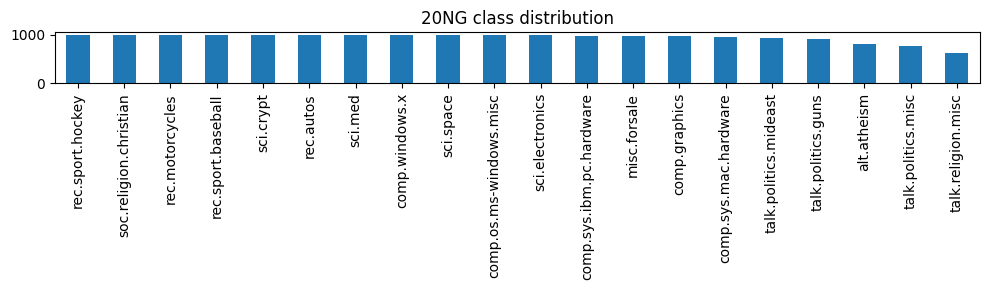

In [6]:
# Class distribution
ng_class_counts = pd.Series(ng_labels).value_counts()
print(ng_class_counts)
ng_class_counts.plot(kind='bar', figsize=(10, 3), title='20NG class distribution')
plt.tight_layout(); plt.show()


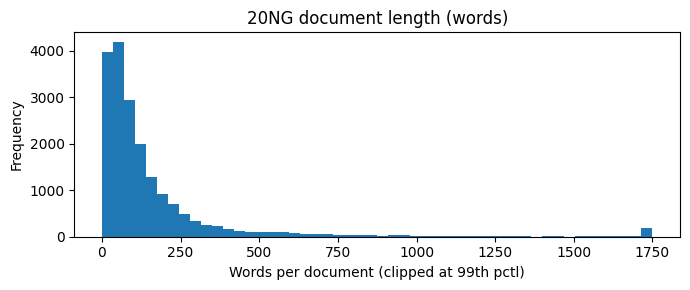

In [7]:
# Document length distribution (in words)
ng_word_lens = [len(d.split()) for d in ng_docs]
length_distribution_plot(ng_word_lens, '20NG document length (words)')


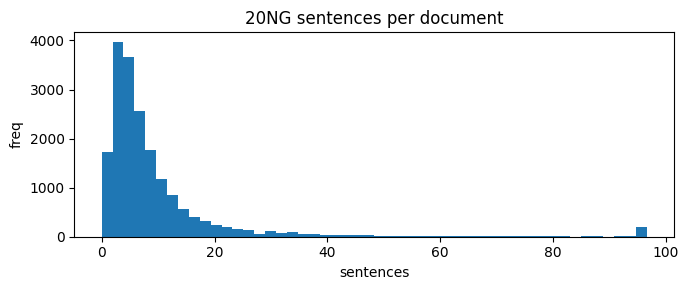

mean sents: 11.076249602037567 median: 6.0


In [8]:
# Sentence count distribution
ng_sent_counts = sentence_counts(ng_docs)
plt.figure(figsize=(7, 3))
plt.hist(np.clip(ng_sent_counts, 0, np.percentile(ng_sent_counts, 99)), bins=50)
plt.title('20NG sentences per document'); plt.xlabel('sentences'); plt.ylabel('freq')
plt.tight_layout(); plt.show()
print('mean sents:', np.mean(ng_sent_counts), 'median:', np.median(ng_sent_counts))


In [9]:
# Vocabulary statistics
ng_vocab = vocab_stats(ng_docs)
for k, v in ng_vocab.items():
    if k != 'top_20':
        print(k, ':', v)
print('top 20 tokens:', ng_vocab['top_20'])


sample_docs : 18846
total_tokens : 3624175
vocab_size : 102465
hapax_count : 49714
hapax_ratio : 0.48518030547016056
top 20 tokens: [('the', 173637), ('to', 86929), ('of', 77247), ('a', 76949), ('and', 70102), ("'ax", 62043), ('i', 52961), ('in', 50933), ('is', 48957), ('that', 44248), ('it', 34213), ('for', 32313), ('you', 28179), ('on', 23634), ('this', 23517), ('be', 22050), ('have', 21323), ('with', 20900), ('are', 20849), ('not', 20693)]


In [10]:
# Examples short/medium/long
show_examples(ng_docs, ng_labels)


--- SHORT (words=0) ---
label: talk.religion.misc


--- MEDIUM (words=83) ---
label: comp.sys.mac.hardware

  Your source is wrong.  The double speed CD300 is still slow compared to a
typical hard disk.  The LC can easily handle the SCSI transfer rate of the
CD300.  None of the current Macs, even the Quadras, support SCSI-2 unless
you get a SCSI-2 Nubus Card.

  You don't have to have double speed to use PhotoCD.  It's just faster
reading images off of a disk.  I think that the CD150 can handle PhotoCD,
but only single session.  The CD300 can do multisession PhotoCD.

--- LONG (words=11765) ---
label: sci.electronics
Since electrical wiring questions do turn up from time to time on
sci.electronics (and the answers aren't always apparent, even to those skilled
in electronics), I am hijacking the following FAQ and posting a copy here. 
I've asked the writers to cross-post to sci.electronics in the future. 

	--- jeh@cmkrnl.com


X-NEWS: cmkrnl news.answers: 6685
Newsgroups: misc.consumer

In [11]:
# Proportion too short / too noisy for sentence-level modelling
print(short_noisy_proportion(ng_docs))


{'n_total': 18846, 'too_short_words_count': 2067, 'too_short_words_pct': 10.967844635466411, 'too_few_sents_pct (sampled)': 9.08}


## 2. RCV1-v2

In [12]:
# RCV1-v2 via sklearn: returns sparse TF-IDF vectors, not raw text
# Raw text requires the licensed NIST distribution
from sklearn.datasets import fetch_rcv1

rcv1 = fetch_rcv1()
print('docs:', rcv1.data.shape[0], '| features (vocab):', rcv1.data.shape[1])
print('labels (categories):', rcv1.target.shape[1])


docs: 804414 | features (vocab): 47236
labels (categories): 103


In [13]:
# Document count
print('total documents:', rcv1.data.shape[0])


total documents: 804414


total categories: 103
CCAT    381327
GCAT    239267
MCAT    204820
C15     151785
ECAT    119920
M14      85440
C151     81890
C152     73092
GPOL     56878
M13      53634
C18      52817
M11      48696
M141     47708
C181     43374
E21      43130
C17      42155
C31      40509
GDIP     37739
C13      37410
GSPO     35317
dtype: uint64


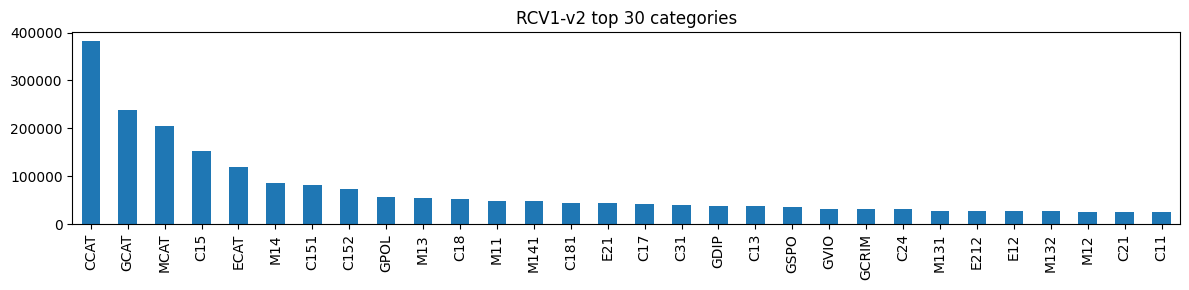

In [14]:
# Class/topic distribution: docs per category (multi-label)
cat_counts = np.asarray(rcv1.target.sum(axis=0)).ravel()
cat_names = rcv1.target_names
cat_series = pd.Series(cat_counts, index=cat_names).sort_values(ascending=False)
print('total categories:', len(cat_series))
print(cat_series.head(20))
cat_series.head(30).plot(kind='bar', figsize=(12, 3), title='RCV1-v2 top 30 categories')
plt.tight_layout(); plt.show()


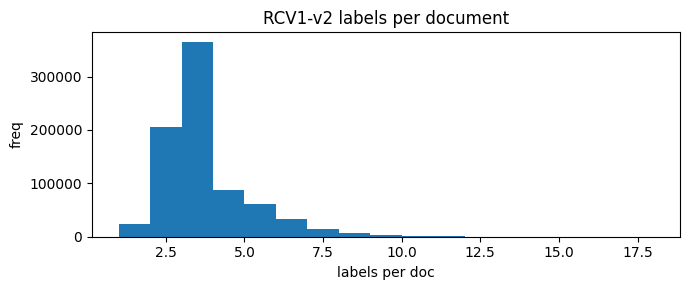

mean labels/doc: 3.2407131153858586 median: 3.0


In [15]:
# Labels per document distribution (multi-label)
labels_per_doc = np.asarray(rcv1.target.sum(axis=1)).ravel()
plt.figure(figsize=(7, 3))
plt.hist(labels_per_doc, bins=range(1, int(labels_per_doc.max())+2))
plt.title('RCV1-v2 labels per document'); plt.xlabel('labels per doc'); plt.ylabel('freq')
plt.tight_layout(); plt.show()
print('mean labels/doc:', labels_per_doc.mean(), 'median:', np.median(labels_per_doc))


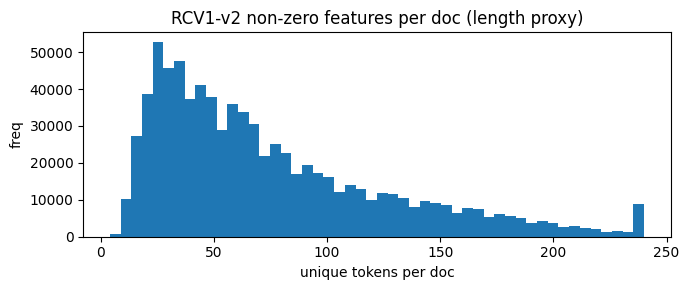

mean unique tokens/doc: 75.7260726441857 median: 60.0


In [16]:
# Document length proxy: number of non-zero TF-IDF features per doc
# This is a proxy for vocabulary richness (raw text not provided by sklearn)
nnz_per_doc = np.asarray((rcv1.data != 0).sum(axis=1)).ravel()
plt.figure(figsize=(7, 3))
plt.hist(np.clip(nnz_per_doc, 0, np.percentile(nnz_per_doc, 99)), bins=50)
plt.title('RCV1-v2 non-zero features per doc (length proxy)')
plt.xlabel('unique tokens per doc'); plt.ylabel('freq')
plt.tight_layout(); plt.show()
print('mean unique tokens/doc:', nnz_per_doc.mean(), 'median:', np.median(nnz_per_doc))


In [17]:
# Vocabulary statistics: full vocab size from feature names
print('vocab size (TF-IDF features):', rcv1.data.shape[1])
# Token frequency from TF-IDF presence
doc_freq = np.asarray((rcv1.data != 0).sum(axis=0)).ravel()
print('tokens appearing in >50%% of docs:', (doc_freq > 0.5 * rcv1.data.shape[0]).sum())
print('hapax-like (tokens in only 1 doc):', (doc_freq == 1).sum())


vocab size (TF-IDF features): 47236
tokens appearing in >50%% of docs: 0
hapax-like (tokens in only 1 doc): 3469


In [18]:
# Note on raw text
# sklearn's fetch_rcv1 does NOT include raw text (only TF-IDF features).
# Sentence count distribution, short/medium/long examples, and sentence-level
# modelling proportion require the licensed NIST RCV1-v2 distribution.
print('Raw text not available via sklearn fetch_rcv1.')
print('Sentence counts and text examples require the licensed NIST distribution.')


Raw text not available via sklearn fetch_rcv1.
Sentence counts and text examples require the licensed NIST distribution.


## 3. LectureBank

In [19]:
# Clone the repo
!rm -rf lecturebank_repo
!git clone --depth 1 https://github.com/Yale-LILY/LectureBank.git lecturebank_repo
!ls lecturebank_repo/


Cloning into 'lecturebank_repo'...
remote: Enumerating objects: 105, done.
remote: Counting objects: 100% (105/105), done.
remote: Compressing objects: 100% (91/91), done.
remote: Total 105 (delta 17), reused 86 (delta 9), pack-reused 0 (from 0)
Receiving objects: 100% (105/105), 1.34 MiB | 4.38 MiB/s, done.
Resolving deltas: 100% (17/17), done.
alldata.tsv  data-versions  LB-Paper  README.md  taxonomy.csv


In [20]:
# Inspect the files
!head -3 lecturebank_repo/alldata.tsv
print('---')
!head -5 lecturebank_repo/taxonomy.csv


ID	Instructor	Title	Topic	URL	Venue	Year
0	Dragomir Radev	NLP Resources	133	http://www.cs.yale.edu/homes/radev/nlpclass/slides2018/133.pptx	Yale	2018
1	Dragomir Radev	Syntax-based Machine Translation	241	http://www.cs.yale.edu/homes/radev/nlpclass/slides2018/455.pptx	Yale	2018
---
Topic ID,Topic,
1,Introduction and Linguistics,
2,"Language Modeling, Syntax, Parsing",
3,Semantics and Logic,
4,"Pragmatics, Discourse, Dialogue, Applications",


In [21]:
# Load alldata.tsv (file has a header row)
lb = pd.read_csv(
    'lecturebank_repo/alldata.tsv',
    sep='\t',
    on_bad_lines='skip'
)
print('shape:', lb.shape)
print('columns:', lb.columns.tolist())
lb.head()


shape: (7500, 7)
columns: ['ID', 'Instructor', 'Title', 'Topic', 'URL', 'Venue', 'Year']


,ID,Instructor,Title,Topic,URL,Venue,Year
0,0,Dragomir Radev,NLP Resources,133,http://www.cs.yale.edu/homes/radev/nlpclass/sl...,Yale,2018
1,1,Dragomir Radev,Syntax-based Machine Translation,241,http://www.cs.yale.edu/homes/radev/nlpclass/sl...,Yale,2018
2,2,Dragomir Radev,Generative and Discriminative Models 1,514,http://www.cs.yale.edu/homes/radev/nlpclass/sl...,Yale,2018
3,3,Dragomir Radev,Tools for Deep Learning,731,http://www.cs.yale.edu/homes/radev/nlpclass/sl...,Yale,2018
4,4,Dragomir Radev,Python Basics,131,http://www.cs.yale.edu/homes/radev/nlpclass/sl...,Yale,2018


In [22]:
# Load taxonomy (has header: Topic ID, Topic)
tax = pd.read_csv('lecturebank_repo/taxonomy.csv')
print('columns:', tax.columns.tolist())
print('taxonomy entries:', len(tax))
tax.head()


columns: ['Topic ID', 'Topic', 'Unnamed: 2']
taxonomy entries: 320


,Topic ID,Topic,Unnamed: 2
0,1,Introduction and Linguistics,NaN
1,2,"Language Modeling, Syntax, Parsing",NaN
2,3,Semantics and Logic,NaN
3,4,"Pragmatics, Discourse, Dialogue, Applications",NaN
4,5,Classification,NaN


In [23]:
# Identify title and topic columns from actual column names
title_col = [c for c in lb.columns if 'title' in c.lower()][0]
topic_col = [c for c in lb.columns if 'topic' in c.lower()][0]
print('title column:', title_col)
print('topic column:', topic_col)


title column: Title
topic column: Topic


In [24]:
# Document count
print('lecture entries:', len(lb))


lecture entries: 7500


In [25]:
# Document text proxy from titles
# (actual slide content requires downloading linked PDFs/PPTs)
lb_docs = lb[title_col].astype(str).tolist()

lb_stats = basic_stats(lb_docs, 'LectureBank (titles)')
pd.Series(lb_stats)


,0
dataset,LectureBank (titles)
n_docs,7500
chars_mean,30.532933
chars_median,27.0
chars_min,2
chars_max,133
words_mean,4.0076
words_median,4.0
words_min,1
words_max,16


unique topic codes in data: 205

top-level topic distribution:
top_topic_name
Introduction and Linguistics                     3611
Neural Networks and Deep Learning                1531
Artificial Intelligence                           753
Other Topics                                      323
Classification                                    300
Information Retrieval and Topic Modeling          283
Pragmatics, Discourse, Dialogue, Applications     240
Language Modeling, Syntax, Parsing                237
Semantics and Logic                               222
Name: count, dtype: int64


/tmp/ipykernel_1378/3960754451.py:21: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(); plt.show()


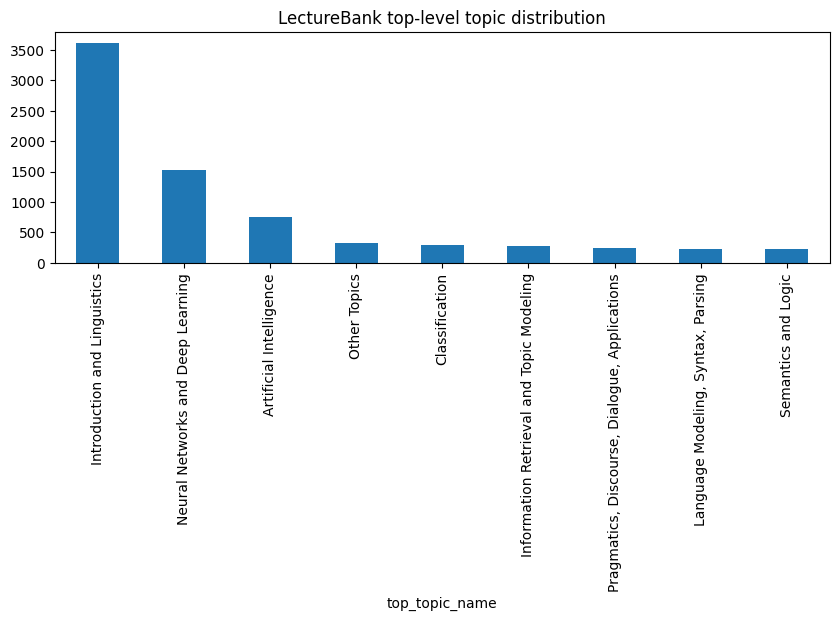

In [26]:
# Topic distribution
# Topic IDs in alldata are hierarchical codes (e.g. 133 = top-level 1, sub 3, sub 3)
# Taxonomy has simple IDs: 1, 2, 3, ... up to ~320
# First digit of topic code maps to top-level taxonomy category
tax_top = dict(zip(tax.iloc[:, 0], tax.iloc[:, 1]))

# Extract first digit as top-level topic
lb['top_topic_id'] = lb[topic_col].astype(str).str[0].astype(int)
lb['top_topic_name'] = lb['top_topic_id'].map(tax_top)

# Full granular topic code count
topic_counts = lb[topic_col].value_counts()
print('unique topic codes in data:', len(topic_counts))
print()

# Top-level topic distribution
top_topic_counts = lb['top_topic_name'].value_counts()
print('top-level topic distribution:')
print(top_topic_counts)
top_topic_counts.plot(kind='bar', figsize=(10, 3), title='LectureBank top-level topic distribution')
plt.tight_layout(); plt.show()


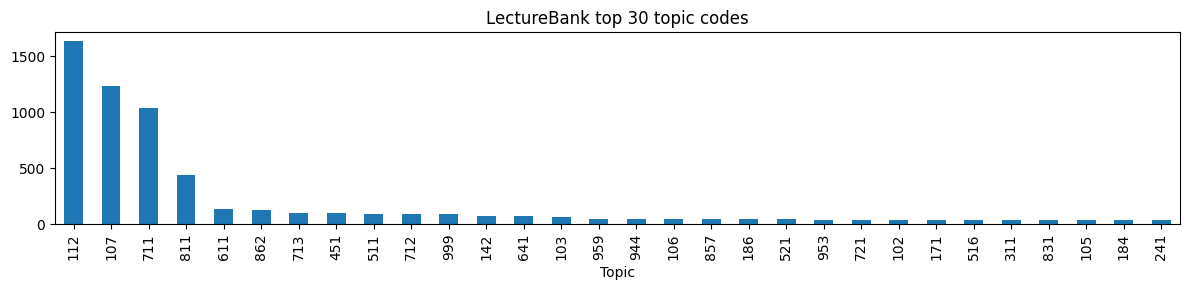

In [27]:
# Full granular topic code distribution (top 30)
topic_counts.head(30).plot(kind='bar', figsize=(12, 3), title='LectureBank top 30 topic codes')
plt.tight_layout(); plt.show()


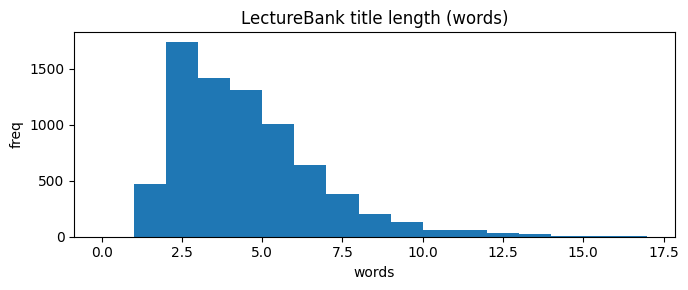

mean words: 4.0076 median: 4.0


In [28]:
# Document length distribution (titles are short)
lb_word_lens = [len(d.split()) for d in lb_docs]
plt.figure(figsize=(7, 3))
plt.hist(lb_word_lens, bins=range(0, max(lb_word_lens)+2))
plt.title('LectureBank title length (words)'); plt.xlabel('words'); plt.ylabel('freq')
plt.tight_layout(); plt.show()
print('mean words:', np.mean(lb_word_lens), 'median:', np.median(lb_word_lens))


In [29]:
# Sentence count distribution (titles are typically single fragments)
lb_sent_counts = [len(sent_tokenize(d)) for d in lb_docs]
print('sentence counts (titles):', Counter(lb_sent_counts))


sentence counts (titles): Counter({1: 7353, 2: 146, 3: 1})


In [30]:
# Vocabulary statistics on titles
lb_vocab = vocab_stats(lb_docs)
for k, v in lb_vocab.items():
    if k != 'top_20':
        print(k, ':', v)
print('top 20 tokens:', lb_vocab['top_20'])


sample_docs : 7500
total_tokens : 29018
vocab_size : 2881
hapax_count : 1201
hapax_ratio : 0.41686914265879904
top 20 tokens: [('and', 1245), ('learning', 901), ('lecture', 779), ('models', 545), ('networks', 542), ('neural', 466), ('language', 407), ('introduction', 400), ('of', 392), ('to', 382), ('deep', 377), ('for', 343), ('machine', 312), ('the', 304), ('in', 268), ('parsing', 230), ('linear', 230), ('classification', 202), ('translation', 192), ('regression', 176)]


In [31]:
# Examples short/medium/long
show_examples(lb_docs)


--- SHORT (words=1) ---
Inference

--- MEDIUM (words=4) ---
Tools for Deep Learning

--- LONG (words=16) ---
The dynamics and regulators of cell fate decisions are revealed by pseudotemporal ordering of single cells



In [32]:
# Proportion too short / too noisy for sentence-level modelling
print(short_noisy_proportion(lb_docs))
print()
print('Note: titles alone are too short for sentence-level modelling.')
print('Real sentence-level EDA needs the linked PDFs/PPTs downloaded and parsed.')


{'n_total': 7500, 'too_short_words_count': 7500, 'too_short_words_pct': 100.0, 'too_few_sents_pct (sampled)': 98.06}

Note: titles alone are too short for sentence-level modelling.
Real sentence-level EDA needs the linked PDFs/PPTs downloaded and parsed.


## Summary

In [33]:
# Combined basic stats for datasets with raw text
summary = pd.DataFrame([ng_stats, lb_stats])
summary


,dataset,n_docs,chars_mean,chars_median,chars_min,chars_max,words_mean,words_median,words_min,words_max
0,20 Newsgroups,18846,1169.667516,489.0,0,158791,181.637748,83.0,0,11765
1,LectureBank (titles),7500,30.532933,27.0,2,133,4.007600,4.0,1,16


In [34]:
# RCV1-v2 summary (raw text not available via sklearn)
rcv1_summary = {
    'dataset': 'RCV1-v2',
    'n_docs': rcv1.data.shape[0],
    'vocab_size_features': rcv1.data.shape[1],
    'mean_unique_tokens_per_doc': float(nnz_per_doc.mean()),
    'mean_labels_per_doc': float(labels_per_doc.mean()),
    'n_categories': rcv1.target.shape[1],
}
pd.Series(rcv1_summary)


,0
dataset,RCV1-v2
n_docs,804414
vocab_size_features,47236
mean_unique_tokens_per_doc,75.726073
mean_labels_per_doc,3.240713
n_categories,103
